# Importing Libraries and preparing dataset.

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import OrdinalEncoder, RobustScaler
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve, accuracy_score,f1_score
from pandas.api.types import is_numeric_dtype
import joblib
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler

In [5]:
# load "titanic" dataset using seaborn library
df = sns.load_dataset("titanic")

In [6]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [7]:
df = df.drop(["deck","embarked", "class"], axis= 1)
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,man,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,man,True,Southampton,no,True


In [8]:
df["sex"].value_counts()

sex
male      577
female    314
Name: count, dtype: int64

In [9]:
df.isna().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
who              0
adult_male       0
embark_town      2
alive            0
alone            0
dtype: int64

In [10]:
df["age"].mean()

np.float64(29.69911764705882)

In [11]:
df["age"]= df["age"].fillna(df["age"].mean())

In [12]:
df["embark_town"].value_counts()

embark_town
Southampton    644
Cherbourg      168
Queenstown      77
Name: count, dtype: int64

In [13]:
df['embark_town'].value_counts()

embark_town
Southampton    644
Cherbourg      168
Queenstown      77
Name: count, dtype: int64

In [14]:
df["embark_town"]=df["embark_town"].ffill()

In [15]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,man,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,man,True,Southampton,no,True


<Axes: xlabel='survived'>

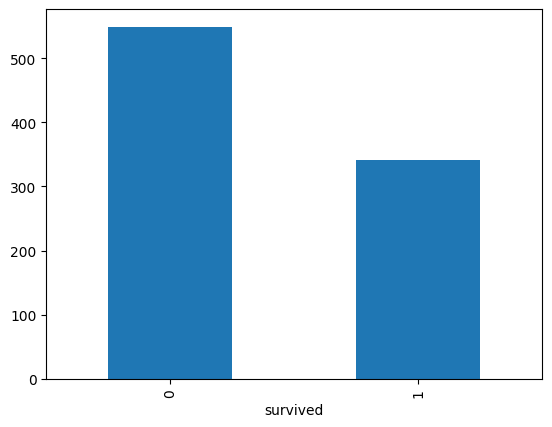

In [16]:
df["survived"].value_counts().plot(kind="bar")

In [17]:
df["survived"].value_counts()

survived
0    549
1    342
Name: count, dtype: int64

In [18]:
df.shape

(891, 12)

<Axes: ylabel='age'>

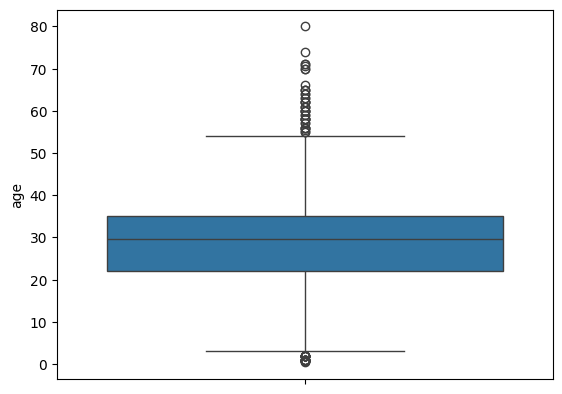

In [19]:
sns.boxplot(df["age"])

In [20]:
ord =OrdinalEncoder()

In [21]:
encod= ord.fit(df[["age"]])

In [22]:
for col in df.columns:
    if not is_numeric_dtype(df[col]):
        df[col]= ord.fit_transform(df[[col]])

In [23]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,who,adult_male,embark_town,alive,alone
0,0,3,1.0,22.0,1,0,7.2500,1.0,True,2.0,0.0,False
1,1,1,0.0,38.0,1,0,71.2833,2.0,False,0.0,1.0,False
2,1,3,0.0,26.0,0,0,7.9250,2.0,False,2.0,1.0,True
3,1,1,0.0,35.0,1,0,53.1000,2.0,False,2.0,1.0,False
4,0,3,1.0,35.0,0,0,8.0500,1.0,True,2.0,0.0,True


In [24]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    float64
 3   age          891 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   who          891 non-null    float64
 8   adult_male   891 non-null    bool   
 9   embark_town  891 non-null    float64
 10  alive        891 non-null    float64
 11  alone        891 non-null    bool   
dtypes: bool(2), float64(6), int64(4)
memory usage: 71.5 KB


In [25]:
df["adult_male"]= df["adult_male"].astype("float64")
df["alone"]= df["alone"].astype("float64")

In [26]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,who,adult_male,embark_town,alive,alone
0,0,3,1.0,22.0,1,0,7.2500,1.0,1.0,2.0,0.0,0.0
1,1,1,0.0,38.0,1,0,71.2833,2.0,0.0,0.0,1.0,0.0
2,1,3,0.0,26.0,0,0,7.9250,2.0,0.0,2.0,1.0,1.0
3,1,1,0.0,35.0,1,0,53.1000,2.0,0.0,2.0,1.0,0.0
4,0,3,1.0,35.0,0,0,8.0500,1.0,1.0,2.0,0.0,1.0


In [27]:
df.drop(["alive"], axis= 1, inplace=True)

In [28]:
# seprate the data 
x= df.drop(["survived"], axis= 1)
y = df[["survived"]]

In [29]:
#split the data 
xtrain, xtest, ytrain, ytest = train_test_split(x,y, test_size=.2, random_state=42)

In [30]:
# apply model 
knn= KNeighborsClassifier()
survive_model = knn.fit(xtrain, ytrain)

C:\Users\User\AppData\Roaming\Python\Python313\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


In [31]:
print("train score")
print(survive_model.score(xtrain, ytrain))

train score
0.8033707865168539


In [32]:
print("test score")
print(survive_model.score(xtest, ytest))

test score
0.7430167597765364


In [33]:
# evaluate 
pred_data = survive_model.predict(xtest)
pred_data

array([0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0,
       0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 1])

In [34]:
ytest

,survived
709,1
439,0
840,0
720,1
39,1
...,...
433,0
773,0
25,1
84,1


In [35]:
# confusion 
cm = confusion_matrix(ytest, pred_data)
cm

array([[92, 13],
       [33, 41]])

<Axes: >

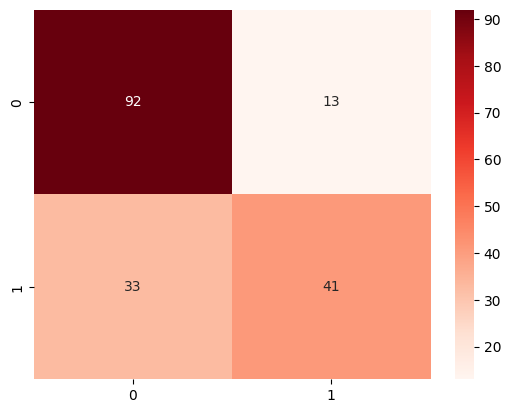

In [36]:
sns.heatmap(cm, annot=True, cmap="Reds")

In [37]:
ytest.value_counts()

survived
0           105
1            74
Name: count, dtype: int64

In [38]:
class_rep = classification_report(ytest, pred_data)
print(class_rep)

              precision    recall  f1-score   support

           0       0.74      0.88      0.80       105
           1       0.76      0.55      0.64        74

    accuracy                           0.74       179
   macro avg       0.75      0.72      0.72       179
weighted avg       0.75      0.74      0.73       179



In [39]:
xtrain

,pclass,sex,age,sibsp,parch,fare,who,adult_male,embark_town,alone
331,1,1.0,45.500000,0,0,28.5000,1.0,1.0,2.0,1.0
733,2,1.0,23.000000,0,0,13.0000,1.0,1.0,2.0,1.0
382,3,1.0,32.000000,0,0,7.9250,1.0,1.0,2.0,1.0
704,3,1.0,26.000000,1,0,7.8542,1.0,1.0,2.0,0.0
813,3,0.0,6.000000,4,2,31.2750,0.0,0.0,2.0,0.0
...,...,...,...,...,...,...,...,...,...,...
106,3,0.0,21.000000,0,0,7.6500,2.0,0.0,2.0,1.0
270,1,1.0,29.699118,0,0,31.0000,1.0,1.0,2.0,1.0
860,3,1.0,41.000000,2,0,14.1083,1.0,1.0,2.0,0.0
435,1,0.0,14.000000,1,2,120.0000,0.0,0.0,2.0,0.0


In [40]:
survive_model.predict([[1,	1.0,	45.500000,	0	,0,	28.5000,	1.0,	1.0,	2.0,	1.0]])

C:\Users\User\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


array([0])

In [41]:
x.columns

Index(['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'who', 'adult_male',
       'embark_town', 'alone'],
      dtype='str')

In [42]:
data = {"pclass": [1],  
        'sex': [0],
        'age':[22], 
        'sibsp':[3], 
        'parch':[5], 
        'fare':[75], 
        'who':[2], 
        'adult_male':[1],
       'embark_town':[2], 
       'alone':[0]}


data_test = pd.DataFrame(data)
data_test

,pclass,sex,age,sibsp,parch,fare,who,adult_male,embark_town,alone
0,1,0,22,3,5,75,2,1,2,0


In [43]:
survive_model.predict(data_test)

array([0])

In [44]:
# model save 
joblib.dump(survive_model, "D:\CreativeIT Class work\Models\ titan_model.lib")

<>:2: SyntaxWarning: invalid escape sequence '\C'
<>:2: SyntaxWarning: invalid escape sequence '\C'
C:\Users\User\AppData\Local\Temp\ipykernel_13340\335259210.py:2: SyntaxWarning: invalid escape sequence '\C'
  joblib.dump(survive_model, "D:\CreativeIT Class work\Models\ titan_model.lib")


['D:\\CreativeIT Class work\\Models\\ titan_model.lib']

In [45]:
# load model 
joblib.load("D:\CreativeIT Class work\Models\ titan_model.lib")

<>:2: SyntaxWarning: invalid escape sequence '\C'
<>:2: SyntaxWarning: invalid escape sequence '\C'
C:\Users\User\AppData\Local\Temp\ipykernel_13340\2783527124.py:2: SyntaxWarning: invalid escape sequence '\C'
  joblib.load("D:\CreativeIT Class work\Models\ titan_model.lib")


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [46]:
# over sampling 
y.value_counts()

survived
0           549
1           342
Name: count, dtype: int64

In [47]:
# over sampling 
ovs= RandomOverSampler()
new_x, new_y = ovs.fit_resample(x,y)

In [48]:
new_x.shape

(1098, 10)

In [49]:
new_y.value_counts()

survived
0           549
1           549
Name: count, dtype: int64

In [50]:
newxtrain, newxtest, newytrain,newytest= train_test_split(new_x, new_y, test_size=.2, random_state=42)

In [51]:
model_over= knn.fit(newxtrain, newytrain)
model_over.score(newxtrain, newytrain)

C:\Users\User\AppData\Roaming\Python\Python313\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


0.8211845102505695

In [52]:
model_over.score(newxtest, newytest)

0.7545454545454545

In [53]:
over_pred = model_over.predict(newxtest)
cm = confusion_matrix(newytest, over_pred)
cm

array([[72, 31],
       [23, 94]])

In [54]:
# smote 
smote = SMOTE()

In [55]:
x_new, y_new= smote.fit_resample(x,y)

In [56]:
y_new.value_counts()

survived
0           549
1           549
Name: count, dtype: int64

In [57]:
x_train, x_test, y_train, y_test= train_test_split(x_new, y_new, test_size=.2, random_state=42)

In [58]:
sm_model = knn.fit(x_train, y_train)
sm_model.score(x_train, y_train)

C:\Users\User\AppData\Roaming\Python\Python313\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


0.8280182232346242

In [59]:
sm_model.score(x_test, y_test)

0.740909090909091

In [60]:
acc_sc = accuracy_score(ytest, pred_data)
acc_sc

0.7430167597765364

In [61]:
# confusion matrix

In [62]:
# undersampling

In [63]:
for i in range(2,30):
    print(f"value of k is {i}")
    knn= KNeighborsClassifier(n_neighbors=i)
    model = knn.fit(xtrain, ytrain)
    print("train score ")
    print(model.score(xtrain, ytrain))
    print("test score ")
    print(model.score(xtest, ytest))

C:\Users\User\AppData\Roaming\Python\Python313\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
C:\Users\User\AppData\Roaming\Python\Python313\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


C:\Users\User\AppData\Roaming\Python\Python313\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
C:\Users\User\AppData\Roaming\Python\Python313\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
C:\Users\User\AppData\Roaming\Python\Python313\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
C:\Users\User\AppData\Roaming\Python\Python313\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was pas

value of k is 2
train score 
0.8356741573033708
test score 
0.6759776536312849
value of k is 3
train score 
0.8342696629213483
test score 
0.7150837988826816
value of k is 4
train score 
0.8146067415730337
test score 
0.7094972067039106
value of k is 5
train score 
0.8033707865168539
test score 
0.7430167597765364
value of k is 6
train score 
0.7823033707865169
test score 
0.7318435754189944
value of k is 7
train score 
0.7963483146067416
test score 
0.7318435754189944
value of k is 8
train score 
0.7794943820224719
test score 
0.7262569832402235
value of k is 9
train score 
0.7823033707865169
test score 
0.7150837988826816
value of k is 10
train score 
0.7626404494382022
test score 
0.6927374301675978
value of k is 11
train score 
0.7626404494382022
test score 
0.7206703910614525
value of k is 12
train score 
0.75
test score 
0.7150837988826816
value of k is 13
train score 
0.7471910112359551
test score 
0.7318435754189944
value of k is 14
train score 
0.7387640449438202
test score 
0

C:\Users\User\AppData\Roaming\Python\Python313\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
C:\Users\User\AppData\Roaming\Python\Python313\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
C:\Users\User\AppData\Roaming\Python\Python313\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
C:\Users\User\AppData\Roaming\Python\Python313\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was pas

0.7206703910614525
value of k is 18
train score 
0.7373595505617978
test score 
0.7150837988826816
value of k is 19
train score 
0.7345505617977528
test score 
0.7094972067039106
value of k is 20
train score 
0.7373595505617978
test score 
0.7318435754189944
value of k is 21
train score 
0.7401685393258427
test score 
0.7374301675977654
value of k is 22
train score 
0.7275280898876404
test score 
0.7318435754189944
value of k is 23
train score 
0.7415730337078652
test score 
0.7541899441340782
value of k is 24
train score 
0.7205056179775281
test score 
0.7206703910614525
value of k is 25
train score 
0.7219101123595506
test score 
0.7206703910614525
value of k is 26
train score 
0.7106741573033708
test score 
0.7262569832402235
value of k is 27
train score 
0.7120786516853933
test score 
0.7262569832402235
value of k is 28
train score 
0.7092696629213483
test score 
0.7206703910614525
value of k is 29
train score 
0.723314606741573
test score 
0.7094972067039106


C:\Users\User\AppData\Roaming\Python\Python313\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
C:\Users\User\AppData\Roaming\Python\Python313\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


In [64]:
# find the best k 
f1_score_train= []
f1_score_test = []
acc_score_train= []
acc_score_test = []


for i in range(2,30):
    #print(f"value of k is {i}")
    knn= KNeighborsClassifier(n_neighbors=i)
    model = knn.fit(xtrain, ytrain)
    #  score train data 
    pred_train = model.predict(xtrain)

    f_sc= f1_score(ytrain, pred_train)
    f1_score_train.append(f_sc)

    acc_sc= accuracy_score(ytrain, pred_train)
    acc_score_train.append(acc_sc)

    #  score test data 
    pred_test = model.predict(xtest)
    f_sc_t= f1_score(ytest, pred_test)
    f1_score_test.append(f_sc_t)

    acc_sc_t= accuracy_score(ytest, pred_test)
    acc_score_test.append(acc_sc_t)

  
    

C:\Users\User\AppData\Roaming\Python\Python313\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
C:\Users\User\AppData\Roaming\Python\Python313\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
C:\Users\User\AppData\Roaming\Python\Python313\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
C:\Users\User\AppData\Roaming\Python\Python313\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was pas

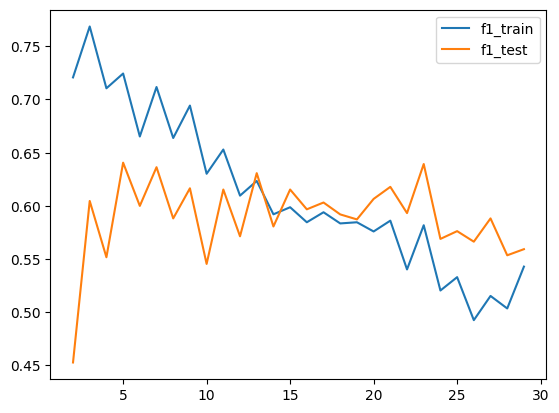

In [65]:
plt.plot(list(range(2,30)),f1_score_train)
plt.plot(list(range(2,30)),f1_score_test)
plt.legend(["f1_train", "f1_test"])

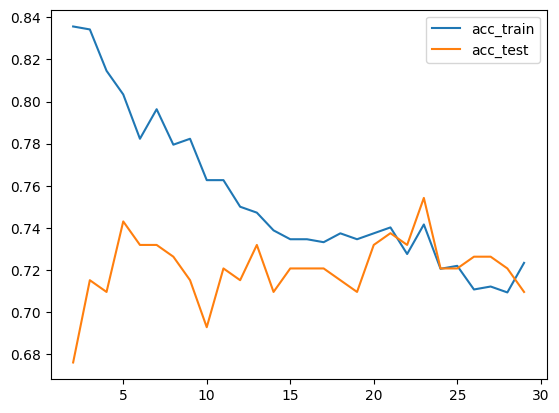

In [66]:
plt.plot(list(range(2,30)),acc_score_train)
plt.plot(list(range(2,30)),acc_score_test)
plt.legend(["acc_train", "acc_test"])